# Note detection on the injected CocoChorales sample

A broad **cached-pitch** sweep on the exact completed `mistake.ipynb` corpus. The current source run has 13 sampled stems, injection seeds 0 and 1, and 26 injected cases. Clean seeds are identical controls and are counted once per source (13 controls).

This is **exploratory tuning on this sample**, not a held-out evaluation. No production defaults are changed. Pitches, injected MIDI, truth events, instrument ranges, voicing gates, and alignment costs are fixed to the saved run. The unrefined production baseline must reproduce every saved case's TP/FP/FN before results are accepted.

The main question is whether `min(cap_ms / 1000, score_factor * shortest_score_note_seconds)` improves note segmentation and downstream mistake F1. `None` means the original uncapped rule. The shortest score duration is taken after the same score-to-pitch tempo fit as production. Caps affect both minimum segment size and the existing KernelCPD penalty.

Spawned workers use all available CPU cores (10 on the current machine), with one numerical-library thread each. Work is split across cases AND pitch-step/silence parameter groups: 780 independently scheduled jobs for the default sample. Long pitch tracks start first, and each worker keeps its current case loaded across jobs. All cap/factor combinations for a given pitch-step/silence pair stay together, so identical frame-level settings share their computation. Every completed job is checkpointed with hashes of the code, pitches, MIDI, truth, configuration and parameter grid.

In [1]:
from pathlib import Path
import sys
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = next(p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
                 if (p / "app.py").is_file())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from benchmarks.modules.note.sweeps.InjectedNoteSweep import Axes, grid, load_cases, run_sweep, PARAMS

SOURCE_RUN = REPO_ROOT / "benchmarks/results/mistake_competitors_coco_extended"
OUTPUT = REPO_ROOT / "benchmarks/results/sweeps/note2"
WORKERS = max(1, os.cpu_count() or 8)  # All available cores; lower this to leave headroom.
RESUME = True
AXES = Axes(
    cap_ms=(30., 50., 60., 80., 100., 150., None),
    score_factor=(.25, .5, .6, .75, 1.),
    pitch_step=(.25, .5, .75, 1., 1.5),
    silence_ms=(3., 10., 20., 40.),
)


## Inspect the fixed sample and grid

The source run determines the sample and injection seeds; no fresh sampling occurs. The grid contains 700 combinations, including the original uncapped production baseline. Only note-detection parameters vary. Vibrato annotation is skipped because it is not consumed by these metrics. Repeat correction is excluded so changes can be attributed to segmentation; finalists should subsequently be checked with the complete production pipeline.

In [2]:
cases, baseline = load_cases(SOURCE_RUN)
variants = grid(AXES, baseline)
sample = pd.DataFrame([{k: c[k] for k in ("case_id", "instrument", "seed", "rate")} for c in cases])
display(sample.groupby(["instrument", "rate"]).size().unstack(fill_value=0).rename_axis(columns="injection rate"))
print("Baseline:", baseline)
print(f"{len(cases)} cases × {len(variants)} variants = {len(cases) * len(variants):,} evaluations")
print("Output:", OUTPUT)


injection rate,0.00,0.25
instrument,,
bassoon,1,2
cello,1,2
clarinet,1,2
double bass,1,2
flute,1,2
horn,1,2
oboe,1,2
saxophone,1,2
trombone,1,2


Baseline: {'cap_ms': None, 'score_factor': 0.6, 'pitch_step': 0.75, 'silence_ms': 10.0}
39 cases × 700 variants = 27,300 evaluations
Output: /Users/sarah/Desktop/shasha/Attune/benchmarks/results/sweeps/note2


## Run the sweep

Reuses compatible per-job checkpoints on rerun. Saved pitch files are read only. The primary score is pooled missed/extra-event F1 at **100 ms / 50 cents**. Also report note onset/pitch F1 at 50, 100 and 200 ms, onset/offset note F1, mistake precision/recall, and clean false alarms. F1 is calculated from pooled TP/FP/FN, never by averaging per-case F1.

In [3]:
rows, summary = run_sweep(SOURCE_RUN, OUTPUT, axes=AXES, workers=WORKERS, resume=RESUME)
metadata = json.loads((OUTPUT / "run.json").read_text())
print(f"Finished in {metadata['wall_seconds']:.1f}s; {metadata['unique_effective_evaluations']:,} distinct case/settings computations")


39 cases × 700 variants = 27,300 evaluations; 780 jobs across 10 workers
780/780 jobs complete
Finished in 58.4s; 8,420 distinct case/settings computations


## Baseline and leading candidates

`clean_safe` means no more false mistake events than the baseline on these clean controls. It is a sample-specific filter, not a guarantee on unseen recordings. Rankings prioritize this constraint, then mistake F1, then note F1. All scores below are percentages; `mistake_f1_gain_pp` is a percentage-point difference.

In [4]:
COLUMNS = PARAMS + ["injected_note100_f1", "injected_audio_pitch100_f1", "injected_precision", "injected_recall",
                   "mistake_f1_gain_pp", "clean_audio_pitch100_fp", "clean_false_alarms_per_100_notes", "clean_safe"]
print("Saved-production baseline")
display(summary.loc[summary.baseline, COLUMNS].round(3))
print("Top 20 candidates, clean-control constraint first")
display(summary[COLUMNS].head(20).round(3))
print("Unconstrained F1 leader (diagnostic)")
display(summary.sort_values("injected_audio_pitch100_f1", ascending=False)[COLUMNS].head(1).round(3))
best = summary.iloc[0]
print("Candidate for independent validation:", {p: best[p] for p in PARAMS})


Saved-production baseline


,cap_ms,score_factor,pitch_step,silence_ms,injected_note100_f1,injected_audio_pitch100_f1,injected_precision,injected_recall,mistake_f1_gain_pp,clean_audio_pitch100_fp,clean_false_alarms_per_100_notes,clean_safe
255,NaN,0.6,0.75,10.0,90.212,76.415,69.231,85.263,0.0,0,0.0,True


Top 20 candidates, clean-control constraint first


,cap_ms,score_factor,pitch_step,silence_ms,injected_note100_f1,injected_audio_pitch100_f1,injected_precision,injected_recall,mistake_f1_gain_pp,clean_audio_pitch100_fp,clean_false_alarms_per_100_notes,clean_safe
0,100.0,0.25,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
1,NaN,0.25,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
2,80.0,0.60,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
3,100.0,0.50,0.75,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
4,80.0,1.00,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
5,80.0,0.50,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
6,100.0,0.60,0.75,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
7,80.0,0.25,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
8,100.0,1.00,0.75,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True
9,150.0,0.25,1.00,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True


Unconstrained F1 leader (diagnostic)


,cap_ms,score_factor,pitch_step,silence_ms,injected_note100_f1,injected_audio_pitch100_f1,injected_precision,injected_recall,mistake_f1_gain_pp,clean_audio_pitch100_fp,clean_false_alarms_per_100_notes,clean_safe
0,100.0,0.25,1.0,40.0,91.071,80.392,75.229,86.316,3.977,0,0.0,True


Candidate for independent validation: {'cap_ms': 100.0, 'score_factor': 0.25, 'pitch_step': 1.0, 'silence_ms': 40.0}


## Duration-cap effects and timing sensitivity

The first table fixes the proposed score factor at 0.5 and holds the other knobs at the saved baseline, isolating the duration cap. The plot shows all combinations; it is descriptive, not independent validation.

,cap_ms,score_factor,pitch_step,silence_ms,injected_note100_f1,injected_audio_pitch100_f1,injected_precision,injected_recall,mistake_f1_gain_pp,clean_audio_pitch100_fp,clean_false_alarms_per_100_notes,clean_safe
557,30.0,0.5,0.75,10.0,85.868,57.246,43.646,83.158,-19.169,36,11.502,False
391,50.0,0.5,0.75,10.0,89.369,72.646,63.281,85.263,-3.769,7,2.236,False
354,60.0,0.5,0.75,10.0,89.871,75.000,66.942,85.263,-1.415,2,0.639,False
181,80.0,0.5,0.75,10.0,90.438,77.885,71.681,85.263,1.470,0,0.000,True
97,100.0,0.5,0.75,10.0,90.658,79.024,73.636,85.263,2.609,0,0.000,True
197,150.0,0.5,0.75,10.0,90.317,77.512,71.053,85.263,1.097,0,0.000,True
215,NaN,0.5,0.75,10.0,90.228,77.143,70.435,85.263,0.728,0,0.000,True


,cap_ms,score_factor,pitch_step,silence_ms,injected_note50_f1,injected_note100_f1,injected_note200_f1,injected_note_offsets_f1,injected_audio_pitch50_f1,injected_audio_pitch100_f1,injected_audio_pitch200_f1
0,100.0,0.25,1.00,40.0,60.390,91.071,98.052,79.221,66.667,80.392,84.314
255,NaN,0.60,0.75,10.0,59.217,90.212,97.227,79.282,63.208,76.415,81.132


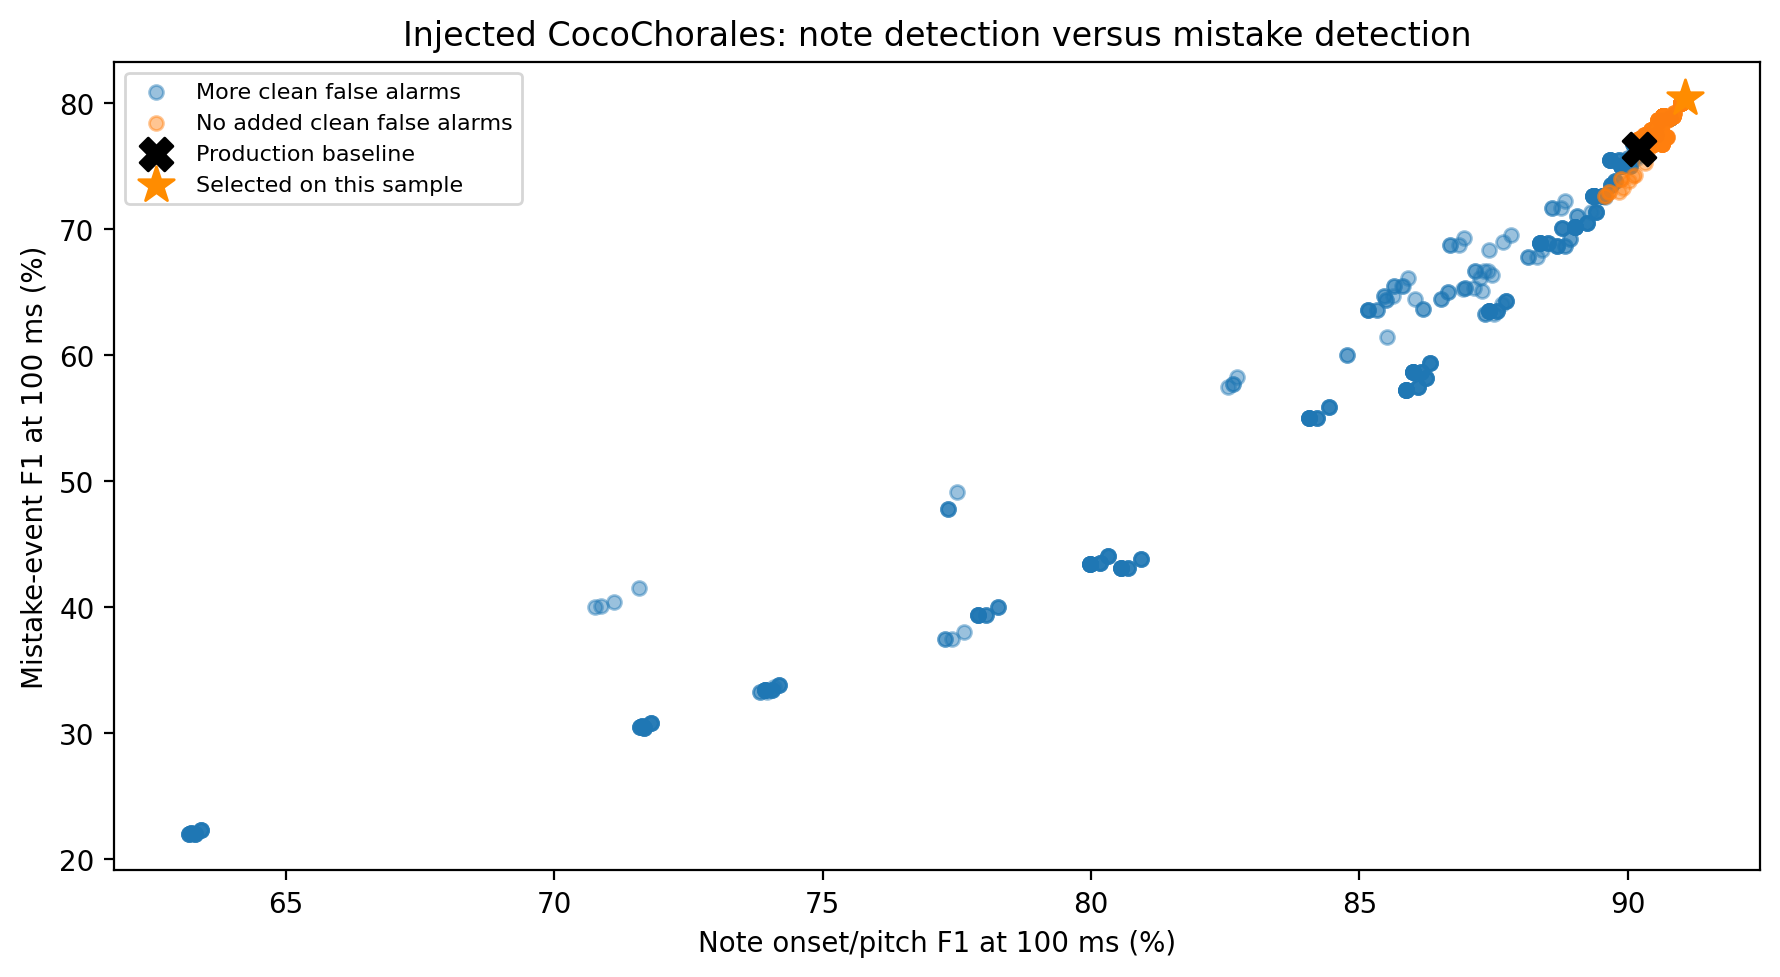

In [5]:
cap_comparison = summary[
    np.isclose(summary.score_factor, .5)
    & np.isclose(summary.pitch_step, baseline["pitch_step"])
    & np.isclose(summary.silence_ms, baseline["silence_ms"])
].sort_values("cap_ms", na_position="last")
display(cap_comparison[COLUMNS].round(3))
selected = summary[summary.baseline | summary.variant.eq(best.variant)]
display(selected[PARAMS + ["injected_note50_f1", "injected_note100_f1", "injected_note200_f1",
                          "injected_note_offsets_f1", "injected_audio_pitch50_f1", "injected_audio_pitch100_f1",
                          "injected_audio_pitch200_f1"]].round(3))
fig, ax = plt.subplots(figsize=(9, 5))
for safe, group in summary.groupby("clean_safe"):
    ax.scatter(group.injected_note100_f1, group.injected_audio_pitch100_f1,
               s=25, alpha=.45, label="No added clean false alarms" if safe else "More clean false alarms")
base_row = summary[summary.baseline].iloc[0]
ax.scatter([base_row.injected_note100_f1], [base_row.injected_audio_pitch100_f1], marker="X", s=140, color="black", label="Production baseline")
ax.scatter([best.injected_note100_f1], [best.injected_audio_pitch100_f1], marker="*", s=180, color="darkorange", label="Selected on this sample")
ax.set(xlabel="Note onset/pitch F1 at 100 ms (%)", ylabel="Mistake-event F1 at 100 ms (%)", title="Injected CocoChorales: note detection versus mistake detection")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Instrument and seed breakdown

Compare the baseline and selected candidate on each instrument and injection seed. Both seeds belong to the tuning sample. This exposes concentration of gains or regressions but does not establish generalization.

In [6]:
comparison = rows[(rows.rate > 0) & (rows.baseline | rows.variant.eq(best.variant))].copy()
comparison["setting"] = np.where(comparison.baseline, "baseline", "selected")
for group_keys in (["instrument", "setting"], ["seed", "setting"]):
    totals = comparison.groupby(group_keys)[["audio_pitch100_tp", "audio_pitch100_fp", "audio_pitch100_fn"]].sum()
    totals["F1 %"] = 200 * totals.audio_pitch100_tp / (2 * totals.audio_pitch100_tp + totals.audio_pitch100_fp + totals.audio_pitch100_fn)
    display(totals.round(3))
print("Before promotion: validate on new chorales, then run the finalists with production repeat correction.")


audio_pitch100_tp  audio_pitch100_fp  audio_pitch100_fn  \
instrument  setting                                                             
bassoon     baseline                  7                  7                  2   
            selected                  7                  7                  2   
cello       baseline                  9                  7                  1   
            selected                  9                  6                  1   
clarinet    baseline                  9                  4                  1   
            selected                  9                  2                  1   
double bass baseline                  7                  3                  3   
            selected                  8                  2                  2   
flute       baseline                  5                  1                  1   
            selected                  5                  1                  1   
horn        baseline                  4                  0                  0   
            selected                  4                  0                  0   
oboe        baseline                  3                  0                  1   
            selected                  3                  0                  1   
saxophone   baseline                  2                  2                  2   
            selected                  2                  2                  2   
trombone    baseline                 10                  5                  0   
            selected                 10                  2                  0   
trumpet     baseline                  8                  1                  2   
            selected                  8                  1                  2   
tuba        baseline                  9                  3                  1   
            selected                  9                  2                  1   
viola       baseline                  4                  1                  0   
            selected                  4                  1                  0   
violin      baseline                  4                  2                  0   
            selected                  4                  1                  0   

                         F1 %  
instrument  setting            
bassoon     baseline   60.870  
            selected   60.870  
cello       baseline   69.231  
            selected   72.000  
clarinet    baseline   78.261  
            selected   85.714  
double bass baseline   70.000  
            selected   80.000  
flute       baseline   83.333  
            selected   83.333  
horn        baseline  100.000  
            selected  100.000  
oboe        baseline   85.714  
            selected   85.714  
saxophone   baseline   50.000  
            selected   50.000  
trombone    baseline   80.000  
            selected   90.909  
trumpet     baseline   84.211  
            selected   84.211  
tuba        baseline   81.818  
            selected   85.714  
viola       baseline   88.889  
            selected   88.889  
violin      baseline   80.000  
            selected   88.889

audio_pitch100_tp  audio_pitch100_fp  audio_pitch100_fn    F1 %
seed setting                                                                  
0    baseline                 28                 13                  3  77.778
     selected                 28                 10                  3  81.159
1    baseline                 53                 23                 11  75.714
     selected                 54                 17                 10  80.000

Before promotion: validate on new chorales, then run the finalists with production repeat correction.
